<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/DataScience_250401020035_NurahmiT/blob/main/Pertemuan12_Nurahmi_Tintyasusi_2504010200352.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---

Langkah 1: Generate & Eksplorasi Dataset Transaksi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Langkah 1: Bangun 50 transaksi sintetis dengan pola pembelian tersembunyi
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Tiap transaksi berisi 2-5 produk unik yang dipilih acak
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    # 2 sampai 5 item
    # str() menjaga item tetap bertipe Python str (bukan numpy.str_),
    # agar association_rules() mlxtend tetap berjalan pada versi mlxtend terbaru
    item = [str(x) for x in np.random.choice(produk, n_item, replace=False)]
    transaksi.append(item)

# Suntikkan pola tersembunyi: Roti sering dibeli bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Jumlah transaksi :', len(transaksi))
print('Contoh 5 transaksi pertama:')
for i, t in enumerate(transaksi[:5], 1):
    print(f'  Transaksi {i}: {t}')

Jumlah transaksi : 50
Contoh 5 transaksi pertama:
  Transaksi 1: ['Sereal', 'Gula', 'Kopi', 'Roti', 'Selai']
  Transaksi 2: ['Telur', 'Mentega', 'Selai']
  Transaksi 3: ['Roti', 'Sereal', 'Selai', 'Teh', 'Susu']
  Transaksi 4: ['Keju', 'Mentega']
  Transaksi 5: ['Kopi', 'Roti', 'Selai']


Langkah 2: One-Hot Encoding Transaksi

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True  False     True  False   True    True   True  False  False
1  False   True   True    False   True   True   False   True  False  False
2   True  False  False     True  False  False    True  False  False  False
3  False  False  False    False   True   True   False  False  False  False
4  False  False   True     True  False  False    True  False  False  False


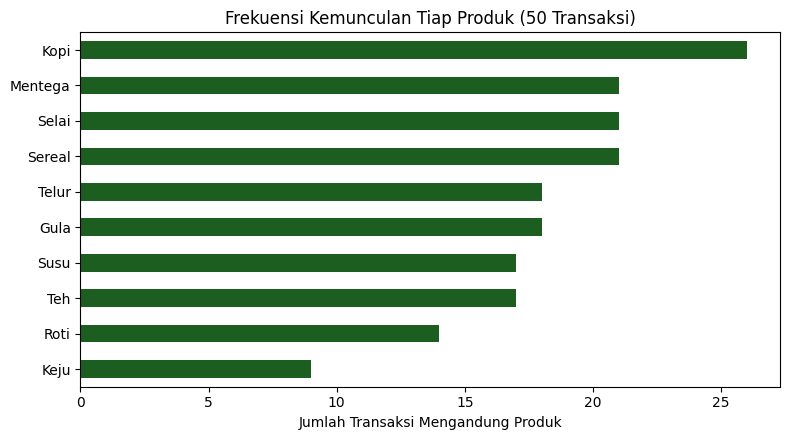

Kopi       26
Mentega    21
Sereal     21
Selai      21
Gula       18
Telur      18
Teh        17
Susu       17
Roti       14
Keju        9
Name: count, dtype: int64


In [12]:
# Eksplorasi: frekuensi kemunculan tiap produk di seluruh transaksi
frekuensi = pd.Series([item for t in transaksi for item in t]).value_counts()

plt.figure(figsize=(8, 4.5))
frekuensi.sort_values().plot(kind='barh', color='#1B5E20')
plt.title('Frekuensi Kemunculan Tiap Produk (50 Transaksi)')
plt.xlabel('Jumlah Transaksi Mengandung Produk')
plt.tight_layout()
plt.show()

print(frekuensi)


In [13]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True  False     True  False   True    True   True  False  False
1  False   True   True    False   True   True   False   True  False  False
2   True  False  False     True  False  False    True  False  False  False
3  False  False  False    False   True   True   False  False  False  False
4  False  False   True     True  False  False    True  False  False  False


### Visualisasi Korelasi Antar Produk (Heatmap)

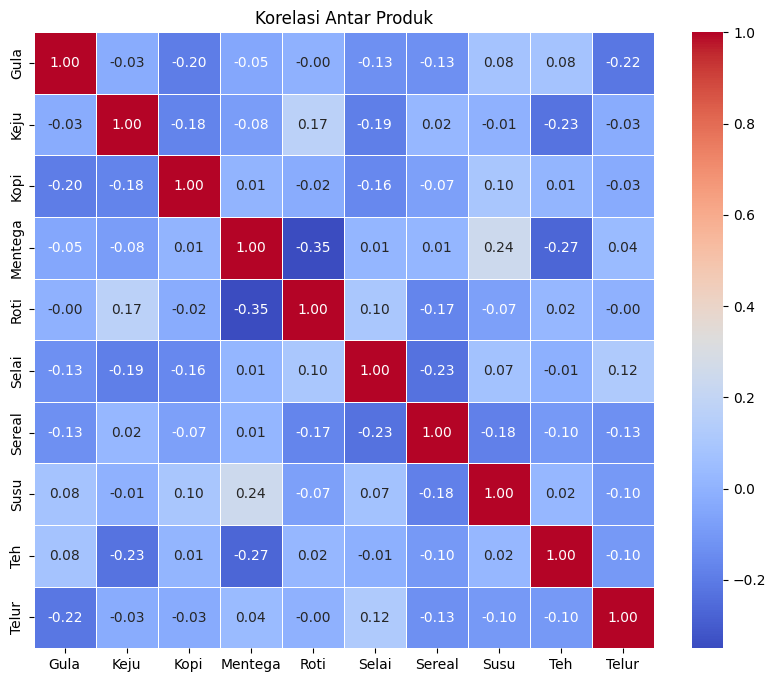

In [5]:
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Korelasi Antar Produk')
plt.show()

Langkah 3: Cari Frequent Itemset dengan Apriori

In [8]:
from mlxtend.frequent_patterns import apriori
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import warnings
warnings.filterwarnings("ignore")

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support yang menghasilkan jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head(10))

min_support=0.05: 86 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support         itemsets
2      0.52           (Kopi)
3      0.42        (Mentega)
6      0.42         (Sereal)
5      0.42          (Selai)
9      0.36          (Telur)
0      0.36           (Gula)
8      0.34            (Teh)
7      0.34           (Susu)
4      0.28           (Roti)
17     0.22  (Kopi, Mentega)


Langkah 4: Bentuk & Saring Aturan Asosiasi

In [9]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence',
                           min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents',
             'support', 'confidence', 'lift']].head(10))

# Interpretasikan dalam sel Markdown:
# Aturan mana yang paling kuat (Lift tertinggi)?
# Apakah masuk akal secara bisnis (mis. Roti -> Selai)?


         antecedents consequents  support  confidence      lift
11     (Selai, Kopi)      (Roti)     0.10    0.555556  1.984127
13      (Kopi, Roti)     (Selai)     0.10    0.714286  1.700680
14  (Selai, Mentega)      (Susu)     0.10    0.555556  1.633987
8    (Kopi, Mentega)      (Susu)     0.12    0.545455  1.604278
15     (Selai, Susu)   (Mentega)     0.10    0.625000  1.488095
9       (Kopi, Susu)   (Mentega)     0.12    0.600000  1.428571
1             (Susu)   (Mentega)     0.20    0.588235  1.400560
12     (Selai, Roti)      (Kopi)     0.10    0.714286  1.373626
3            (Telur)     (Selai)     0.18    0.500000  1.190476
16   (Mentega, Susu)     (Selai)     0.10    0.500000  1.190476


Langkah 5: Rekomender Sederhana dengan Content-Based Filtering

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
katalog = pd.DataFrame({
    'produk':   produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

# One-hot encoding kategori -> vektor fitur tiap produk
fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

print('Katalog produk:')
print(katalog.to_string(index=False))

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    # urutkan dari paling mirip, buang produk itu sendiri
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

for p in ['Roti', 'Susu', 'Kopi']:
    print(f'Mirip dengan {p:<5}:', rekomendasi_serupa(p))


Katalog produk:
 produk kategori
   Roti   Bakery
  Selai   Bakery
   Susu    Dairy
 Sereal   Bakery
  Telur    Dairy
   Keju    Dairy
   Kopi  Minuman
   Gula    Bumbu
    Teh  Minuman
Mentega    Dairy
Mirip dengan Roti : ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu : ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi : ['Teh', 'Roti', 'Selai']


Langkah 6: Bandingkan Kedua Pendekatan

In [16]:
# Langkah 6: Bandingkan rekomendasi untuk produk target yang sama
produk_target = 'Roti'

# (A) Dari Association Rules: consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)].copy()
rules_terkait['consequents'] = rules_terkait['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'=== Rekomendasi untuk "{produk_target}" ===\n')
print('(A) Dari ASSOCIATION RULES (pola beli bersama):')
if len(rules_terkait):
    print(rules_terkait[['consequents', 'confidence', 'lift']].round(3).to_string(index=False))
else:
    print('  (tidak ada aturan lolos untuk produk ini)')

# (B) Dari Content-Based Filtering: produk dengan kategori paling mirip
print('\n(B) Dari CONTENT-BASED (kemiripan kategori):')
print(' ', rekomendasi_serupa(produk_target))

=== Rekomendasi untuk "Roti" ===

(A) Dari ASSOCIATION RULES (pola beli bersama):
consequents  confidence  lift
      Selai       0.714 1.701
       Kopi       0.714 1.374
      Selai       0.500 1.190

(B) Dari CONTENT-BASED (kemiripan kategori):
  ['Selai', 'Sereal', 'Susu']


Kesimpulan

Kedua pendekatan, Association Rules dan Content-Based Filtering, menunjukkan konsistensi dalam merekomendasikan 'Selai' ketika 'Roti' dibeli. Ini mengindikasikan bahwa 'Roti' dan 'Selai' adalah pasangan produk yang kuat. Namun, ada perbedaan dalam rekomendasi lainnya:

Association Rules menemukan pola pembelian aktual dari data transaksi (misalnya, pembeli 'Roti' dan 'Gula' cenderung membeli 'Selai'). Ini cocok untuk rekomendasi cross-selling atau bundle produk.
Content-Based Filtering menemukan produk yang serupa berdasarkan atribut (dalam kasus ini, kategori). Ini berguna untuk rekomendasi produk baru atau untuk pelanggan yang belum memiliki riwayat pembelian yang cukup.
Strategi terbaik adalah menggabungkan keduanya (Hybrid Approach), di mana sistem dapat menggunakan association rules untuk rekomendasi berdasarkan perilaku pembelian populer, lalu melengkapi dengan content-based untuk menyarankan item serupa yang relevan secara fungsional. Ini akan memberikan rekomendasi yang lebih kaya, relevan, dan beragam.

